In [1]:
print("hello")

hello


In [2]:
# imbalanced dataset
from collections import Counter
from sklearn.datasets import make_classification
import pandas as pd

In [3]:
#n_cluster_per_class means hwo many cluster for each particular class it means 1 cluster for one class
X,Y = make_classification(n_samples = 10000,n_features=2,n_clusters_per_class = 1,n_redundant = 0,weights=[0.99],random_state = 10)


In [4]:
pd.DataFrame(Y).value_counts()

0
0    9846
1     154
Name: count, dtype: int64

In [5]:
import seaborn as sns


<Axes: xlabel='0', ylabel='1'>

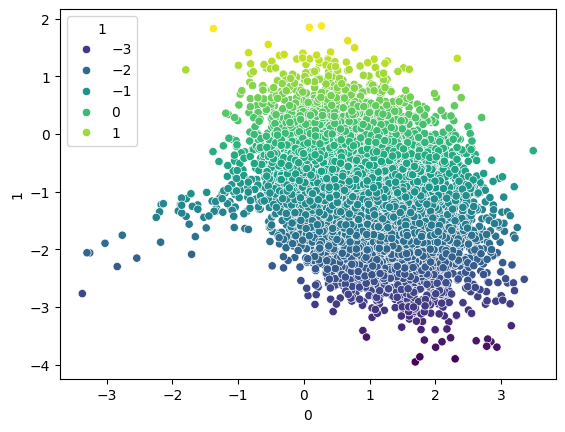

In [6]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(X)
# Assumes y_labels contains your categories (e.g., 0, 1, 2 or 'Red', 'Blue')
# This creates a color gradient based on the values in column 1
sns.scatterplot(x=df[0], y=df[1], hue=df[1], palette="viridis",legend =True)


<Axes: xlabel='0', ylabel='1'>

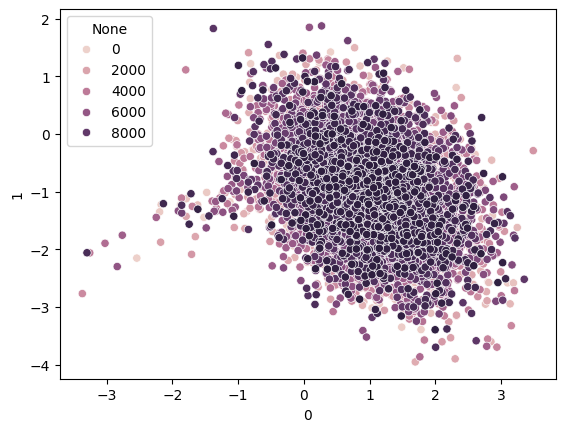

In [7]:
sns.scatterplot(x=df[0], y=df[1], hue=df.index, legend=True)

<Axes: xlabel='0', ylabel='1'>

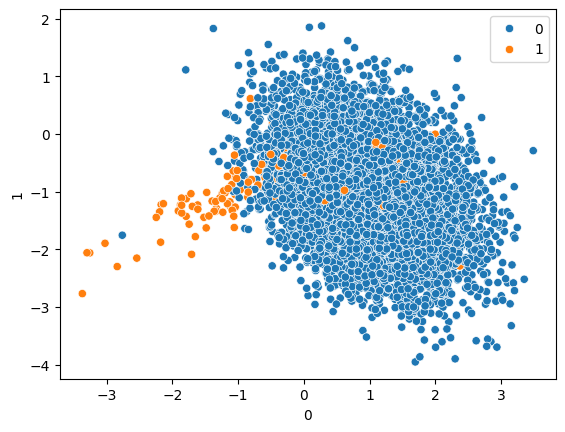

In [8]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(X)

# explicitly ensure y is passed as your hue
sns.scatterplot(x=df[0], y=df[1], hue=Y)

In coding and data visualization libraries like Seaborn, hue is a parameter used to colour data points based on a specific variable or category.
## What it Does

* Groups Data: It splits your data points into different groups based on the values in that column.
* Assigns Colours: It gives each distinct group its own unique colour.
* Creates a Legend: It automatically builds a legend mapping each colour back to its group name (like 0 and 1).

## A Real-World Analogy
Imagine you have a bucket of marbles and a grid drawn on the floor.

* x tells you how far right to place a marble.
* y tells you how far forward to place a marble.
* hue tells you what colour paint to put on that marble based on its team (Team 0 or Team 1).

## Visual Example
Without hue, all your points look identical:

* sns.scatterplot(x=df[0], y=df[1]) $\rightarrow$ All points are blue.

With hue, Seaborn separates them by category:

* sns.scatterplot(x=df[0], y=df[1], hue=category_column) $\rightarrow$ Group 0 is blue, Group 1 is orange.

To help you hook this up correctly in your code, please let me know:

* What variable name in your notebook holds your 0 and 1 values?
* Is that variable a separate list/array, or is it a column inside df?
* Do you want to pick custom colours for your 0 and 1 groups?




In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.25,random_state =0)

In [10]:
class_weight = [{0: w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [11]:
### Hyperparameter Tuning
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
penalty = ['l1','l2','elasticnet']
c_values = [100,10,1.0,.1,0.01]
solver = ['newton-cg','lbfgs','liblinear','sag','saga']
class_weight = [{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [12]:
params = dict(penalty = penalty,C = c_values,solver = solver,class_weight=class_weight)

In [13]:
params


{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [14]:
from sklearn.model_selection import GridSearchCV
# Fixed: changed 'model_Selection' to 'model_selection'
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
grid = GridSearchCV(estimator=model, param_grid=params,
                    scoring='accuracy', cv=cv)

In [15]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


grid.fit(X_train,Y_train)

c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

## import warnings
## warnings.filterwarnings("ignore")


In [16]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [17]:
grid_predict = grid.predict(X_test)


In [18]:
grid_predict

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [19]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
score = accuracy_score(Y_test, grid_predict)
print(score)
cm = confusion_matrix(Y_test, grid_predict)
print(cm)
print(classification_report(Y_test, grid_predict))

0.9912
[[2465    5]
 [  17   13]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2470
           1       0.72      0.43      0.54        30

    accuracy                           0.99      2500
   macro avg       0.86      0.72      0.77      2500
weighted avg       0.99      0.99      0.99      2500



## Logistic Regression with ROC curve and ROC AUC

we are thinking that that logistic regression is by default using the 0.5 to categorize the 1 and 0 values

In [20]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import pandas as pd



In [21]:
X,Y = make_classification(n_samples = 1000,n_classes = 2,random_state = 1)

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.25,random_state = 42)

In [23]:
dummy_model_prob  =[0 for _ in range(len(Y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [24]:
model = LogisticRegression()
model.fit(X_train,Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
model_prob

NameError: name 'model_prob' is not defined

In [26]:
model_prob = model.predict_proba(X_test)

In [29]:
dummy_model_auc= roc_auc_score(Y_test,dummy_model_prob)
# Change this line:
# model_auc = roc_auc_score(Y_test, model_prob)

# To this:
model_auc = roc_auc_score(Y_test, model_prob[:, 1])

In [30]:
print(dummy_model_auc)
print(model_auc)

0.5
0.9108885464817668


## 1. Overview
The ROC (Receiver Operating Characteristic) curve is a graph showing a classification model's performance at all probability thresholds. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR). The AUC (Area Under the Curve) measures the entire two-dimensional area underneath the ROC curve, indicating how well the model separates classes.

---

## 2. Key Formulas

* **True Positive Rate (TPR) / Sensitivity / Recall**

$$\text{TPR} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$

* **False Positive Rate (FPR) / (1 - Specificity)**

$$\text{FPR} = \frac{\text{False Positives (FP)}}{\text{False Positives (FP)} + \text{True Negatives (TN)}}$$

* **AUC Calculation (Trapezoidal Rule)**

$$\text{AUC} = \sum_{i} \frac{1}{2} (\text{FPR}_{i} - \text{FPR}_{i-1}) (\text{TPR}_{i} + \text{TPR}_{i-1})$$

---

## 3. Interpreting the AUC Score

* **$\text{AUC} = 1.0$**: A perfect model that flawlessly separates positive and negative classes.
* **$\text{AUC} = 0.5$**: A random guessing model with no predictive value.
* **$\text{AUC} < 0.5$**: Worse than random guessing, indicating inverted predictions.
* **$\text{AUC} > 0.8$**: Generally considered an excellent classifier.

---

## 4. Core Mechanics

* **Threshold Sliding:** Shifting classification probability thresholds continuously alters TPR and FPR values.
* **Curve Shape:** Better-performing models curve sharply toward the top-left corner.
* **Ranking Probability:** AUC represents the probability that a random positive instance ranks higher than a random negative instance.


In [ ]:
# 1. Generate probabilities (gives 2 columns)
raw_probs = model.predict_proba(X_test)

# 2. Keep only the positive class (column 1)
model_prob = raw_probs[:, 1]

# 3. Now all downstream metrics will work perfectly without changing syntax:
model_auc = roc_auc_score(Y_test, model_prob)
model_fpr, model_tpr, _ = roc_curve(Y_test, model_prob)

In [34]:
model_fpr

array([0.        , 0.        , 0.        , 0.00757576, 0.00757576,
       0.01515152, 0.01515152, 0.02272727, 0.02272727, 0.03030303,
       0.03030303, 0.03787879, 0.03787879, 0.04545455, 0.04545455,
       0.0530303 , 0.0530303 , 0.06060606, 0.06060606, 0.06818182,
       0.06818182, 0.08333333, 0.08333333, 0.09090909, 0.09090909,
       0.09848485, 0.09848485, 0.11363636, 0.11363636, 0.12121212,
       0.12121212, 0.12878788, 0.12878788, 0.15909091, 0.15909091,
       0.18181818, 0.18181818, 0.18939394, 0.18939394, 0.20454545,
       0.20454545, 0.21969697, 0.21969697, 0.22727273, 0.22727273,
       0.24242424, 0.24242424, 0.31060606, 0.31060606, 0.32575758,
       0.32575758, 0.38636364, 0.38636364, 0.40909091, 0.40909091,
       0.41666667, 0.41666667, 0.53030303, 0.53030303, 0.53787879,
       0.53787879, 1.        ])

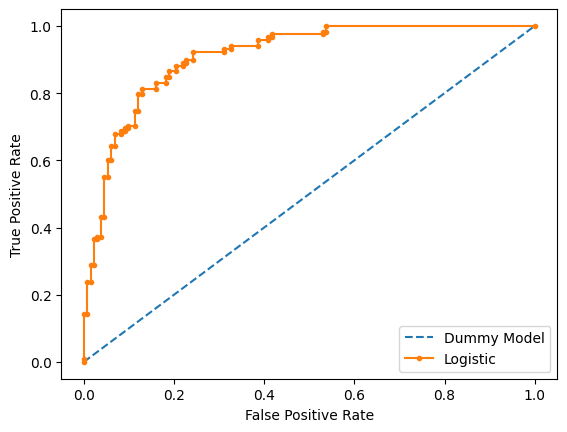

In [38]:
import matplotlib.pyplot as plt
plt.plot(dummy_fpr,dummy_tpr,linestyle='--',label="Dummy Model")
plt.plot(model_fpr,model_tpr,marker='.',label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [39]:
_

array([           inf, 9.99738397e-01, 9.87033757e-01, 9.86362468e-01,
       9.57744551e-01, 9.57101721e-01, 9.45385188e-01, 9.40463485e-01,
       9.28300276e-01, 9.27356342e-01, 9.25607881e-01, 9.23728474e-01,
       8.94744248e-01, 8.94036983e-01, 8.43395917e-01, 8.38396411e-01,
       8.28791784e-01, 8.26684852e-01, 8.08489957e-01, 8.06352720e-01,
       7.80393330e-01, 7.63976766e-01, 7.63705186e-01, 7.63537905e-01,
       7.58496683e-01, 7.55347574e-01, 7.52623720e-01, 7.48020931e-01,
       7.23488083e-01, 7.23238629e-01, 6.74619385e-01, 6.56791269e-01,
       6.55162225e-01, 6.26882105e-01, 5.99962989e-01, 5.57931518e-01,
       5.39053079e-01, 5.14219160e-01, 5.05342549e-01, 4.96278090e-01,
       4.90154702e-01, 4.85201910e-01, 4.69275954e-01, 4.50983178e-01,
       4.46563018e-01, 4.39872005e-01, 4.24245353e-01, 3.24715881e-01,
       3.12906913e-01, 3.06694053e-01, 3.01325247e-01, 2.10358834e-01,
       2.06296724e-01, 1.91030219e-01, 1.69877066e-01, 1.42771985e-01,
      

In [43]:
thresholds = _

In [45]:
thresholds

array([           inf, 9.99738397e-01, 9.87033757e-01, 9.86362468e-01,
       9.57744551e-01, 9.57101721e-01, 9.45385188e-01, 9.40463485e-01,
       9.28300276e-01, 9.27356342e-01, 9.25607881e-01, 9.23728474e-01,
       8.94744248e-01, 8.94036983e-01, 8.43395917e-01, 8.38396411e-01,
       8.28791784e-01, 8.26684852e-01, 8.08489957e-01, 8.06352720e-01,
       7.80393330e-01, 7.63976766e-01, 7.63705186e-01, 7.63537905e-01,
       7.58496683e-01, 7.55347574e-01, 7.52623720e-01, 7.48020931e-01,
       7.23488083e-01, 7.23238629e-01, 6.74619385e-01, 6.56791269e-01,
       6.55162225e-01, 6.26882105e-01, 5.99962989e-01, 5.57931518e-01,
       5.39053079e-01, 5.14219160e-01, 5.05342549e-01, 4.96278090e-01,
       4.90154702e-01, 4.85201910e-01, 4.69275954e-01, 4.50983178e-01,
       4.46563018e-01, 4.39872005e-01, 4.24245353e-01, 3.24715881e-01,
       3.12906913e-01, 3.06694053e-01, 3.01325247e-01, 2.10358834e-01,
       2.06296724e-01, 1.91030219e-01, 1.69877066e-01, 1.42771985e-01,
      

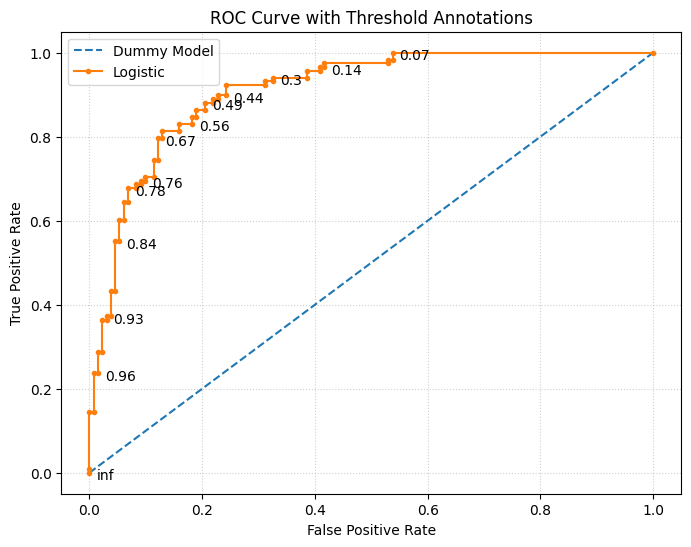

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axis correctly first
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the dummy model (baseline)
ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')

# Plot the Logistic model (marker is just 'marker', not 'markers')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')

# Annotate thresholds onto the curve (using string formatting and correct xy tuples)
# Note: We step through the thresholds so the graph doesn't get overcrowded with numbers
for i, xyz in enumerate(zip(model_fpr, model_tpr, thresholds)):
    if i % 5 == 0:  # Annotate every 5th point to keep the plot readable
        ax.annotate(
            f"{np.round(xyz[2], 2)}",
            xy=(xyz[0], xyz[1]),
            textcoords="offset points",
            xytext=(5, -5),
            ha='left'
        )

# Set labels and legend using the standard plt interface
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Threshold Annotations')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
a